<a href="https://colab.research.google.com/github/JSebast08/DataXperience-ProyectoVideojuegosSteam-Ean/blob/main/ProyectoVideojuegosSteam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Análisis de Videojuegos en Steam**

## **Etapa 1: Carga, Exploración y Limpieza**

### **Librerias**

In [61]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### **Dataset**

In [62]:
df = pd.read_csv('/content/steam.csv', index_col=[0])


filas = df.shape[0]
columnas = df.shape[1]
print("Filas:", filas)
print("Columnas:", columnas)


df.head()


Filas: 27103
Columnas: 17


,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
0,Counter-Strike,2000-11-01,Valve,0,124534,3339,17612,7.19€,15000000.0,True,False,False,False,False,False,False,False
1,Team Fortress Classic,1999-04-01,Valve,0,3318,633,277,3.99€,7500000.0,True,False,False,False,False,False,False,False
2,Day of Defeat,2003-05-01,Valve,0,3416,398,187,3.99€,7500000.0,True,False,False,False,False,False,False,False
3,Deathmatch Classic,2001-06-01,Valve,0,1273,267,258,3.99€,7500000.0,True,False,False,False,False,False,False,False
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,0,5250,288,624,3.99€,7500000.0,True,False,False,False,False,False,False,False


###**Limpieza de Datos**

#### Duplicados

In [63]:
df.duplicated().value_counts()

,count
False,27075
True,28


In [64]:
df.drop_duplicates(inplace=True)

#### Errores de formato o estructura

In [65]:
df.sample(20)

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
1038,The Blackwell Legacy,2012-01-13,Wadjet Eye Games,8,848,107,0,3.99€,150000.0,False,True,False,False,False,False,False,False
26727,Greed 3: Old Enemies Returning,2019-03-11,Urchin Games,0,9,1,0,6.99€,10000.0,False,False,False,False,False,False,False,False
15095,High clear VR,2017-06-28,FiveStarGames,0,34,8,0,14.99€,10000.0,True,False,False,False,False,False,False,False
9481,Vistascapes VR,2016-07-08,Bird Man Games,0,13,16,0,1.99€,10000.0,True,True,False,True,False,False,False,False
18019,Destroy Space Aliens,2017-11-29,"Flying Fire, LLC",30,7,2,0,7.19€,10000.0,True,True,False,False,False,False,False,False
24011,Dream Enders RPG,2019-02-08,C.A.Withey,0,9,0,0,0.0€,10000.0,False,True,True,False,False,False,True,True
20676,Infernales: Circles of Hell,2018-03-16,VGstudio,0,5,4,0,4.79€,10000.0,True,True,False,False,False,False,False,False
4816,Incognito,2015-03-23,Maxwolf;Fox,21,16,18,278,5.59€,35000.0,True,True,False,False,False,False,False,False
17918,Happy Neighbors,2017-11-08,Ionel Zeveleanu,4,13,0,0,2.89€,10000.0,False,False,False,False,False,False,False,False
16027,Magic Potion Destroyer,2017-09-26,ARTIFACTS,48,15,5,0,6.99€,10000.0,False,False,False,False,True,False,False,False


In [66]:
df.dtypes

,0
name,object
release_date,object
developer,object
achievements,int64
positive_ratings,int64
negative_ratings,int64
avg_hours_per_user,int64
price,object
sells,float64
action,bool


##### Errores Encontrados

###### Errores:

- Quitar simbolo € para convertir a numero
- Convertir release_date a formato fecha
- Convertir sells a entero
- Validar si existen juegos sin categoria y agregar columna sin categoria para esos juegos
- Eliminar nulos

In [67]:
# convertir precio a número
df['price'] = df['price'].str.replace('€', '').astype(float)

# convertir fecha
df['release_date'] = pd.to_datetime(df['release_date'])

#Sells a entero
df['sells'] = df['sells'].astype(int)


In [68]:
#Generos
generos = ['action', 'adventure', 'rpg', 'simulation', 'strategy', 'racing', 'free_to_play', 'early_access']

#Juegos sin categorias
df['total_categorias'] = df[generos].sum(axis=1)

df[df['total_categorias'] == 0]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,total_categorias
26,Rag Doll Kung Fu,2005-10-12,Mark Healey,0,40,17,0,5.99,35000,False,False,False,False,False,False,False,False,0
33,Multiwinia,2008-09-19,Introversion Software,12,368,75,121,7.19,750000,False,False,False,False,False,False,False,False,0
41,Source Filmmaker,2012-07-10,Valve,0,15083,1111,239,0.00,1500000,False,False,False,False,False,False,False,False,0
62,Gumboy - Crazy Adventures™,2006-12-19,"CINEMAX, s.r.o.",0,52,46,0,0.00,75000,False,False,False,False,False,False,False,False,0
90,Zuma Deluxe,2006-08-30,"PopCap Games, Inc.",0,437,37,267,4.25,150000,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27056,"Hello, World.",2019-04-19,Meatball Parm Games,0,0,1,0,2.89,10000,False,False,False,False,False,False,False,False,0
27058,Nyasha Valkyrie,2019-04-19,Zloy Krot Studio,32,7,0,0,0.79,10000,False,False,False,False,False,False,False,False,0
27059,Peas Adventure,2019-04-18,Artur Rezende,0,1,0,0,0.79,10000,False,False,False,False,False,False,False,False,0
27061,Blacksmith Run,2019-04-19,Skull Box Games,0,13,0,0,0.79,10000,False,False,False,False,False,False,False,False,0


In [69]:
#Agregamos columna 'uncategorized'
df['uncategorized'] = df['total_categorias'] == 0

# Eliminamos columna total_categorias
df = df.drop(columns=['total_categorias'])

In [70]:
#Eliminar los NA
df.isna()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27071,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27072,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27073,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [71]:
#Identificamos variable con nulos
df.isna().any()

,0
name,False
release_date,False
developer,True
achievements,False
positive_ratings,False
negative_ratings,False
avg_hours_per_user,False
price,False
sells,False
action,False


In [72]:
#Identificamos fila con NAN

df[df["developer"].isna()]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized
23071,The Battle Of Ages,2018-09-07,NaN,0,2,1,0,3.99,10000,True,False,True,False,False,False,False,True,False


In [73]:
"""
Se identificó un valor nulo en la variable "developer".
Dado que este dato podía ser inferido a partir del nombre del juego,
se realizó una imputación manual para conservar la observación y evitar pérdida de información.
"""

df.loc[df['developer'].isna(), 'developer'] = 'None'
df[df['name']== 'The Battle Of Ages']

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized
23071,The Battle Of Ages,2018-09-07,None,0,2,1,0,3.99,10000,True,False,True,False,False,False,False,True,False


#### Nuevas Columnas

In [74]:
# Nuevas Columnas para anilisis futuros

# Total de valoraciones recibidas
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

# Ratio de aprobación (0 = pésimo, 1 = perfecto)
# Evitamos división por cero con .replace()
df['rating_ratio'] = df['positive_ratings'] / df['total_ratings'].replace(0, pd.NA)

In [75]:
sin_ratings = (df['total_ratings'] == 0).sum()
print(f"Juegos sin ninguna valoración: {sin_ratings}")

Juegos sin ninguna valoración: 0


### Resumen Dataset Depurado


Este dataset contiene información de 27,075 juegos publicados en Steam.
Se eligió por su relación directa con la industria del software y el desarrollo
de aplicaciones, áreas centrales en Ingeniería de Sistemas. Permite analizar
factores que determinan el éxito comercial de un producto de software,
como precio, género, valoraciones de usuarios y horas de uso promedio.

In [76]:

print("=== RESUMEN DEL DATASET DEPURADO ===\n")
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print(f"\nValores nulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nTipos de variables:")
print(df.dtypes)
print("\nEjemplo del dataset limpio:")
df.head(3)

=== RESUMEN DEL DATASET DEPURADO ===

Filas: 27075  |  Columnas: 20

Valores nulos restantes:
Series([], dtype: int64)

Tipos de variables:
name                          object
release_date          datetime64[ns]
developer                     object
achievements                   int64
positive_ratings               int64
negative_ratings               int64
avg_hours_per_user             int64
price                        float64
sells                          int64
action                          bool
adventure                       bool
rpg                             bool
simulation                      bool
strategy                        bool
racing                          bool
free_to_play                    bool
early_access                    bool
uncategorized                   bool
total_ratings                  int64
rating_ratio                 float64
dtype: object

Ejemplo del dataset limpio:


,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized,total_ratings,rating_ratio
0,Counter-Strike,2000-11-01,Valve,0,124534,3339,17612,7.19,15000000,True,False,False,False,False,False,False,False,False,127873,0.973888
1,Team Fortress Classic,1999-04-01,Valve,0,3318,633,277,3.99,7500000,True,False,False,False,False,False,False,False,False,3951,0.839787
2,Day of Defeat,2003-05-01,Valve,0,3416,398,187,3.99,7500000,True,False,False,False,False,False,False,False,False,3814,0.895648


## **Etapa 2: Estadísticas Descriptivas**

### **Medidas de Tendencia Central**

In [77]:
#Definimos variables numericas
numericas = ['price', 'sells', 'achievements', 'positive_ratings',
             'negative_ratings', 'avg_hours_per_user',
             'total_ratings', 'rating_ratio']

tendencia_central = pd.DataFrame({
    'Media':    df[numericas].mean().round(2),
    'Mediana':  df[numericas].median().round(2),
    'Moda':     df[numericas].mode().iloc[0].round(2)
})


tendencia_central

,Media,Mediana,Moda
price,6.08,3.99,3.99
sells,134090.49,10000.00,10000.00
achievements,45.25,7.00,0.00
positive_ratings,1000.56,24.00,1.00
negative_ratings,211.03,9.00,0.00
avg_hours_per_user,149.80,0.00,0.00
total_ratings,1211.59,36.00,1.00
rating_ratio,0.71,0.76,1.00


####Interpretación — Tendencia Central

- Price

  El precio promedio de los juegos es de 6.08€, pero la mediana es menor (3.99€).
  Esto nos dice que hay algunos juegos bastante caros que están empujando el promedio hacia arriba.

  Además, el valor más frecuente también es 3.99€, lo que sugiere que este precio es muy común, especialmente en juegos indie. En otras palabras, parece ser un precio “normal” dentro de Steam.

- Sells

  El promedio de ventas es 134,090, pero la mediana es solo 10,000.

  Esto indica que la mayoría de los juegos venden relativamente poco, mientras que unos pocos tienen ventas extremadamente altas elevando el promedio. Es una distribución desigual.

  También se identifica que la moda es 10,000, lo que podría indicar que ese valor es un mínimo reportado por Steam, más que una cifra real exacta.

- Achivments

  El número de logros presenta una media de 45.25, pero una mediana mucho menor (7.00), lo que indica una distribución claramente sesgada hacia la derecha.

  Esto significa que, aunque algunos juegos tienen una gran cantidad de logros, la mayoría tiene pocos. Además, la moda es 0, lo que muestra que el valor más común es que los juegos no tengan logros.
  
- Ratings

  En valoraciones positivas, el promedio es cercano a 1,000, pero la mediana es apenas 24.
  Esto refuerza la idea de que solo unos pocos juegos concentran la mayoría de las opiniones.

  Por otro lado, el rating_ratio tiene un promedio de 0.71 y una mediana de 0.76, lo que indica que, en general, los juegos son bien valorados (más del 70% de aprobación).

  Sin embargo, la moda es 1.00, lo que significa que muchos juegos tienen 100% de aprobación. Esto probablemente ocurre en juegos con muy pocas reseñas, donde uno o dos votos positivos influyen mucho en el resultado.

- avg_hours_per_user

  La mediana es 0, lo cual es una señal preocupante.

  Esto significa que más de la mitad de los juegos tienen registradas 0 horas promedio por usuario, lo que nos brinda dos opciones:
  Hay problemas en los datos, o muchos juegos realmente no tienen actividad significativa por parte de los usuarios.

In [78]:
ceros_horas = (df['avg_hours_per_user'] == 0).sum()
total = len(df)
print(f"Juegos con 0 horas promedio: {ceros_horas} ({ceros_horas/total*100:.1f}%)")

Juegos con 0 horas promedio: 20905 (77.2%)


#### Nota sobre avg_hours_per_user
El 77.2% de los juegos registra 0 horas promedio por usuario,
posiblemente porque Steam no reporta datos de juegos con baja actividad.

In [79]:
sin_logros = (df['achievements'] == 0).sum()
print(f"Juegos sin logros: {sin_logros} ({sin_logros/len(df)*100:.1f}%)")

Juegos sin logros: 11864 (43.8%)


#### Nota sobre achievements
El 43.8% de los juegos registra 0 logros, esto sugiere que implementar logros es una decisión de diseño que diferencia juegos más elaborados de producciones simples

### **Medidas Disperción**

In [80]:
dispersion = pd.DataFrame({
    'Rango':    df[numericas].max() - df[numericas].min(),
    'Varianza': df[numericas].var().round(2),
    'Std':      df[numericas].std().round(2),
    'CV (%)':   (df[numericas].std() / df[numericas].mean() * 100).round(2)
})


dispersion

,Rango,Varianza,Std,CV (%)
price,4.219900e+02,6.201000e+01,7.87,129.56
sells,1.499900e+08,1.763819e+12,1328088.58,990.44
achievements,9.821000e+03,1.243763e+05,352.67,779.40
positive_ratings,2.644404e+06,3.605717e+08,18988.72,1897.81
negative_ratings,4.870760e+05,1.836070e+07,4284.94,2030.52
avg_hours_per_user,1.906250e+05,3.338068e+06,1827.04,1219.61
total_ratings,3.046716e+06,5.030643e+08,22429.09,1851.22
rating_ratio,1.000000e+00,5.000000e-02,0.23,32.69


####Interpretación — Tendencia Central

- Price

  El precio tiene una desviación estándar de 7.87€, que es incluso mayor que su media. Sin embargo, al comparar con otras variables, es la que presenta el coeficiente de variación más bajo por lo que se llega a la conclusión de que es la variable más “estable” del dataset.

  Ya que, aunque los precios varían, lo hacen dentro de rangos razonables y esperados dentro del mercado.

-  Sells

    La variabilidad es muy alta y la desviación estándar supera el millón de ventas (1,328,088).

    El coeficiente de variación cercano al 1000% confirma que las ventas no están equilibradas, se puede deducir que unos pocos juegos generan la gran mayoría de las ventas, mientras que la mayoría de juegos tiene cifras muy bajas.

    Esto refuerza la idea de que el éxito en videojuegos no está distribuido de forma uniforme.
  
- Achievements

  La variabilidad en los logros es bastante alta. El rango alcanza los 9,821, lo que evidencia que existen juegos con una cantidad extremadamente alta de logros, mientras que muchos otros tienen cero.

  La desviación estándar (352.67) es muy elevada en comparación con la media (45.25), lo que confirma esta gran dispersión.

- Ratings

  Las variables de valoraciones positivas y negativas presentan los niveles más altos de dispersión del dataset, alrededor del 1900%.

  Esto indica que la cantidad de reseñas también está altamente concentrada en pocos juegos, lo cual coincide con lo observado anteriormente:
  la popularidad está dominada por un grupo reducido de títulos.

- rating_ratio

  Esta es la variable más estable de todas, con un coeficiente de variación de 32.69%.

  Su desviación es baja dentro de una escala que va de 0 a 1, lo que indica que los valores son bastante consistentes.

- avg_hours_per_user

  Esta variable presenta una dispersión muy alta (1219.61%), lo cual está alineado con lo observado en las medidas de tendencia central para esta variable.

  La presencia de muchos valores en cero hace que la variabilidad aumente considerablemente, lo que puede afectar su interpretación y analisis.

- **Importante**

  Las variables de ventas y ratings presentan CV superiores al 900%, lo que indica una distribución asimetrica.Esto puede darse por la presencia de outliers significativos que deberan ser analizados.
  
  Adicionalmente para tener en cuenta, rating_ratio (CV=32.69%) es la
  variable más homogénea y representativa del dataset.

### **Outliers**

In [81]:

print("=== OUTLIERS ===\n")

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]

    print(f"  {col}")
    print(f"   Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"   Límite inferior: {limite_inf:.2f} | Límite superior: {limite_sup:.2f}")
    print(f"   Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n")

=== OUTLIERS ===

  price
   Q1: 1.69 | Q3: 7.19 | IQR: 5.50
   Límite inferior: -6.56 | Límite superior: 15.44
   Outliers detectados: 1975 (7.3%)

  sells
   Q1: 10000.00 | Q3: 35000.00 | IQR: 25000.00
   Límite inferior: -27500.00 | Límite superior: 72500.00
   Outliers detectados: 5420 (20.0%)

  achievements
   Q1: 0.00 | Q3: 23.00 | IQR: 23.00
   Límite inferior: -34.50 | Límite superior: 57.50
   Outliers detectados: 1695 (6.3%)

  positive_ratings
   Q1: 6.00 | Q3: 126.00 | IQR: 120.00
   Límite inferior: -174.00 | Límite superior: 306.00
   Outliers detectados: 4286 (15.8%)

  negative_ratings
   Q1: 2.00 | Q3: 42.00 | IQR: 40.00
   Límite inferior: -58.00 | Límite superior: 102.00
   Outliers detectados: 3957 (14.6%)

  avg_hours_per_user
   Q1: 0.00 | Q3: 0.00 | IQR: 0.00
   Límite inferior: 0.00 | Límite superior: 0.00
   Outliers detectados: 6170 (22.8%)

  total_ratings
   Q1: 10.00 | Q3: 176.00 | IQR: 166.00
   Límite inferior: -239.00 | Límite superior: 425.00
   Outlie

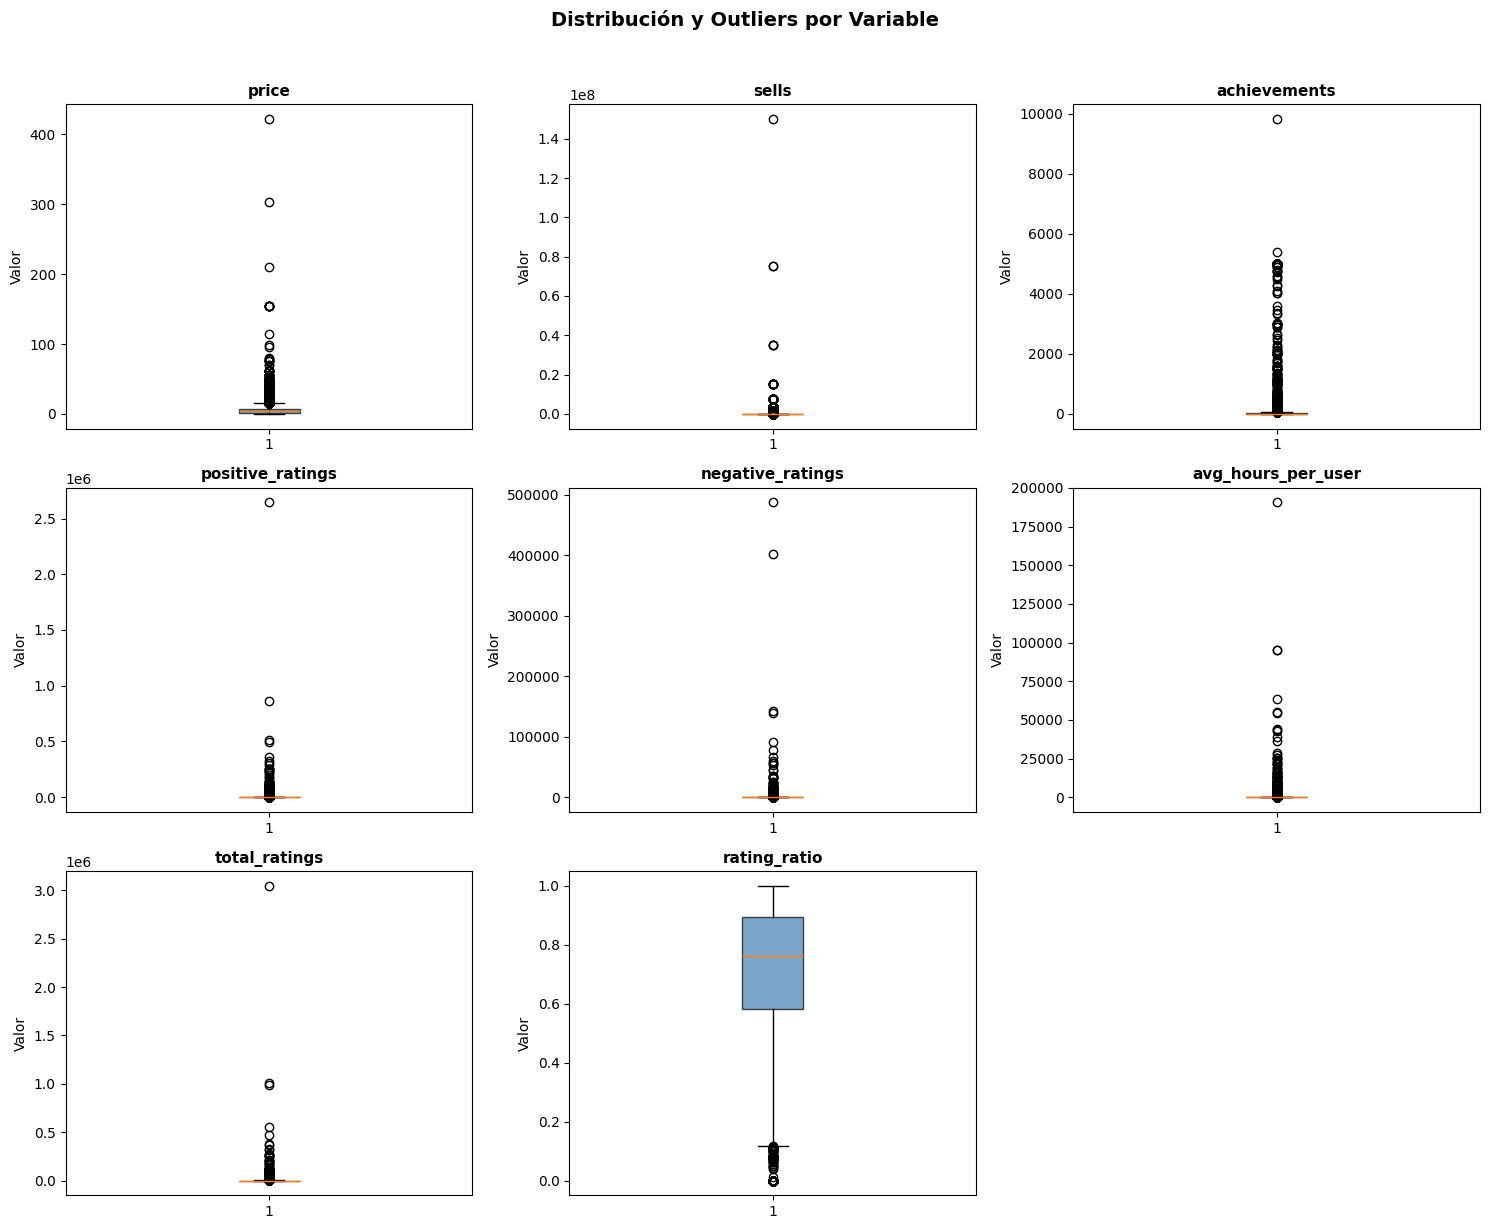

In [82]:
#  Boxplots para visualizar outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valor')

# Ocultar el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución y Outliers por Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [83]:
df.describe()

,release_date,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,total_ratings,rating_ratio
count,27075,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,2.707500e+04,27075.000000
mean,2016-12-31 14:21:17.252077568,45.248864,1.000559e+03,211.027147,149.804949,6.078193,1.340905e+05,1.211586e+03,0.714478
min,1997-06-30 00:00:00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+04,1.000000e+00,0.000000
25%,2016-04-04 00:00:00,0.000000,6.000000e+00,2.000000,0.000000,1.690000,1.000000e+04,1.000000e+01,0.583333
50%,2017-08-08 00:00:00,7.000000,2.400000e+01,9.000000,0.000000,3.990000,1.000000e+04,3.600000e+01,0.760331
75%,2018-06-06 12:00:00,23.000000,1.260000e+02,42.000000,0.000000,7.190000,3.500000e+04,1.760000e+02,0.893905
max,2019-05-01 00:00:00,9821.000000,2.644404e+06,487076.000000,190625.000000,421.990000,1.500000e+08,3.046717e+06,1.000000
std,NaN,352.670281,1.898872e+04,4284.938531,1827.038141,7.874922,1.328089e+06,2.242909e+04,0.233594


In [84]:
df[df['achievements'] == 9821]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized,total_ratings,rating_ratio
12604,LOGistICAL,2017-02-15,Sacada,9821,125,35,0,6.99,75000,False,False,False,False,True,False,False,False,False,160,0.78125


In [85]:
df[df['avg_hours_per_user'] == 190625]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized,total_ratings,rating_ratio
9201,The Abbey of Crime Extensum,2016-05-19,Manuel Pazos;Daniel Celemín,0,146,22,190625,0.0,75000,False,True,False,False,False,False,True,False,False,168,0.869048


In [86]:
df[df['price'] == 421.99]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access,uncategorized,total_ratings,rating_ratio
21105,ADR-Labelling Game,2018-04-12,Suomen Kuljetusturva Oy,0,1,0,0,421.99,10000,False,False,False,True,False,False,False,False,False,1,1.0


#### Análisis de Outliers — Método IQR

Se aplicó el Rango Intercuartílico (IQR) para detectar outliers
en todas las variables numéricas. A continuación se resumen los hallazgos
y las decisiones tomadas:

| Variable           | Outliers | % del dataset | Decisión        |
|--------------------|----------|---------------|-----------------|
| price              | 1,975    | 7.3%          | Se conservan*   |
| sells              | 5,420    | 20.0%         | Se conservan*   |
| achievements       | 1,695    | 6.3%          | Se conservan*   |
| positive_ratings   | 4,286    | 15.8%         | Se conservan*   |
| negative_ratings   | 3,957    | 14.6%         | Se conservan*   |
| avg_hours_per_user | 6,170    | 22.8%         | 1 fila eliminada|
| total_ratings      | 4,204    | 15.5%         | Se conservan*   |
| rating_ratio       | 727      | 2.7%          | Se conservan*   |

*Los outliers conservados corresponden a juegos reales con alta
popularidad (ej. Counter-Strike, Team Fortress) cuya variabilidad
es inherente a la industria de videojuegos.

**Correcciones puntuales realizadas:**
- avg_hours_per_user = 190,625 → fila eliminada (dato consultado en la web, no coincide con la realidad del juego)
- price de 'ADR-Labelling Game': corregido de 421.99€ a 49.99€
  (validado en la página oficial de Steam)


In [87]:
#Eliminar fila con dato erróneo en avg_hours_per_user
df = df[df['avg_hours_per_user'] != 190625]
print(f"Filas restantes: {len(df)}")

#Corregir valor errado
df[df['price'] == 421.99]
df.loc[df['name'] == 'ADR-Labelling Game', 'price'] = 49.99

Filas restantes: 27074


### Matriz de Correlación

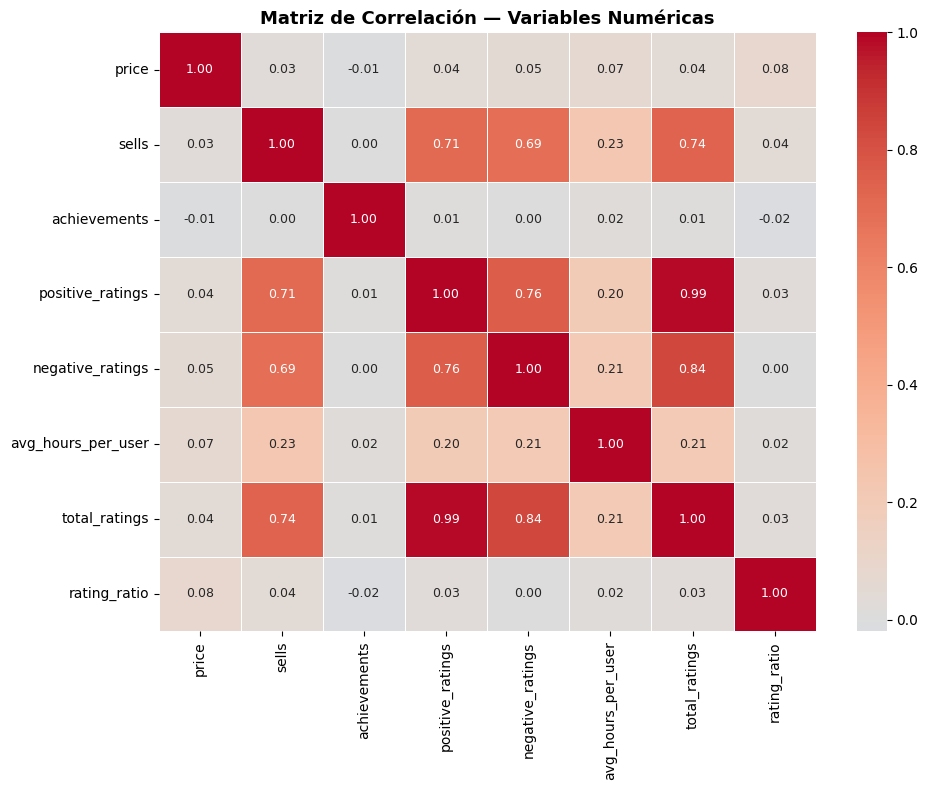

In [88]:
correlacion = df[numericas].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Matriz de Correlación — Variables Numéricas',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

####Interpretación — Matriz de Correlación

**Correlaciones fuertes (> 0.70):**

Se observan relaciones importantes entre las variables relacionadas con las ventas y las valoraciones. La relación entre ventas (sells) y ratings positivos (positive_ratings) es de 0.71, lo que indica que los juegos que más venden también suelen acumular más opiniones positivas. Es una relacion logica dado que a mayor número de ventas, mayor cantidad de personas dejando reseñas.

Algo similar ocurre con ratings negativos (negative_ratings), que tienen una correlación de 0.69 con las ventas. Esto no significa que los juegos sean malos, sino que al tener más exposición, reciben más opiniones en general, tanto positivas como negativas.

La correlación más alta con ventas se da con total_ratings (0.74), lo que confirma que la popularidad de un juego está fuertemente ligada al volumen de reseñas que genera.

**Correlaciones débiles:**

El precio (price) prácticamente no tiene relación con las ventas (0.03), lo que sugiere que el costo del juego no es un factor determinante en su éxito comercial.

De forma similar, los logros (achievements) no muestran una relación con las ventas (0.00), indicando que esta característica no influye en qué tanto vende un juego.

Para finalizar, el rating_ratio (0.04),no tiene una relación significativa con las ventas.Esto sugiere que tener buenas valoraciones no necesariamente se traduce en más ventas.

## **Etapa 3: Visualizaciones y Modelo**

### Visualizaciones

En esta sección se presentan 7 visualizaciones que responden preguntas
clave sobre el mercado de videojuegos en Steam, conectando los hallazgos
estadísticos de la Etapa 2.

| # | Visualización | Pregunta que responde |
|---|---|---|
| 1 | Top 10 juegos por ventas | ¿Qué juegos dominan el mercado? |
| 2 | Ventas por género | ¿Qué géneros venden más? |
| 3 | Precio vs Ventas | ¿El precio determina el éxito? |
| 4 | Free-to-play vs de pago | ¿Los juegos gratis venden más? |
| 5 | Free-to-play vs Reviews | ¿Los juegos gratis tienen mejores reviews? |
| 6 | Evolución de achievements | ¿Cómo han evolucionado los logros por año? |
| 7 | Horas jugadas por género | ¿Qué géneros generan más engagement? |

##### 	Top 10 juegos por ventas

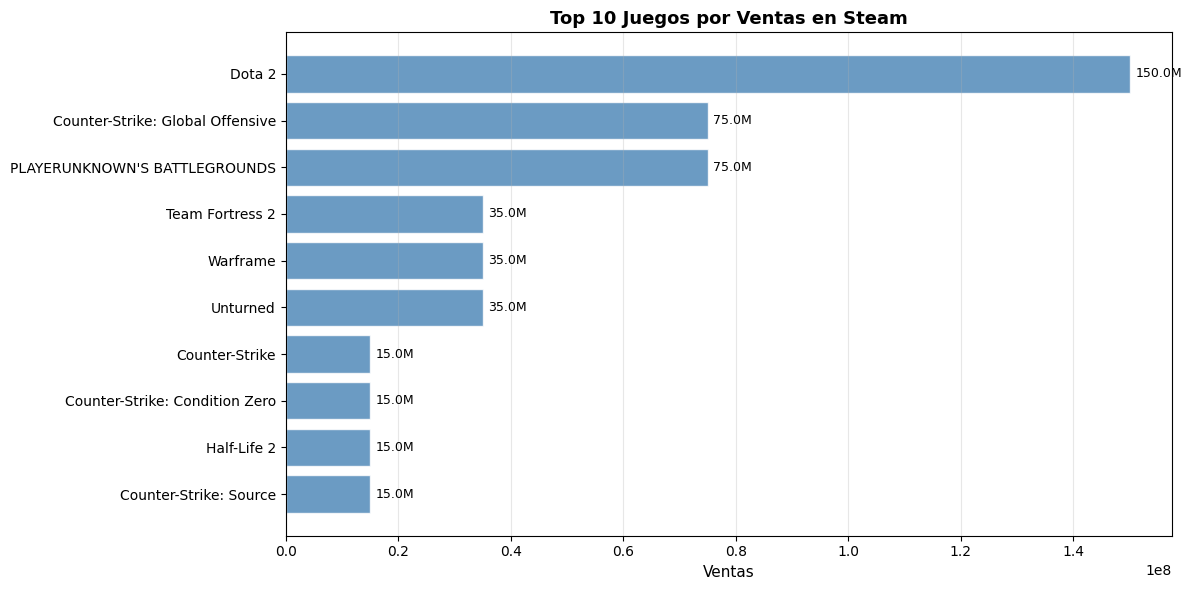

In [89]:

top10 = df.nlargest(10, 'sells')[['name', 'sells']].reset_index(drop=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['name'], top10['sells'],
                color='steelblue', alpha=0.8, edgecolor='white')

# Etiquetas de valor en cada barra
for bar, val in zip(bars, top10['sells']):
    plt.text(bar.get_width() + 1e6, bar.get_y() + bar.get_height()/2,
             f'{val/1e6:.1f}M', va='center', fontsize=9)

plt.xlabel('Ventas', fontsize=11)
plt.title('Top 10 Juegos por Ventas en Steam',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### 	Ventas por género

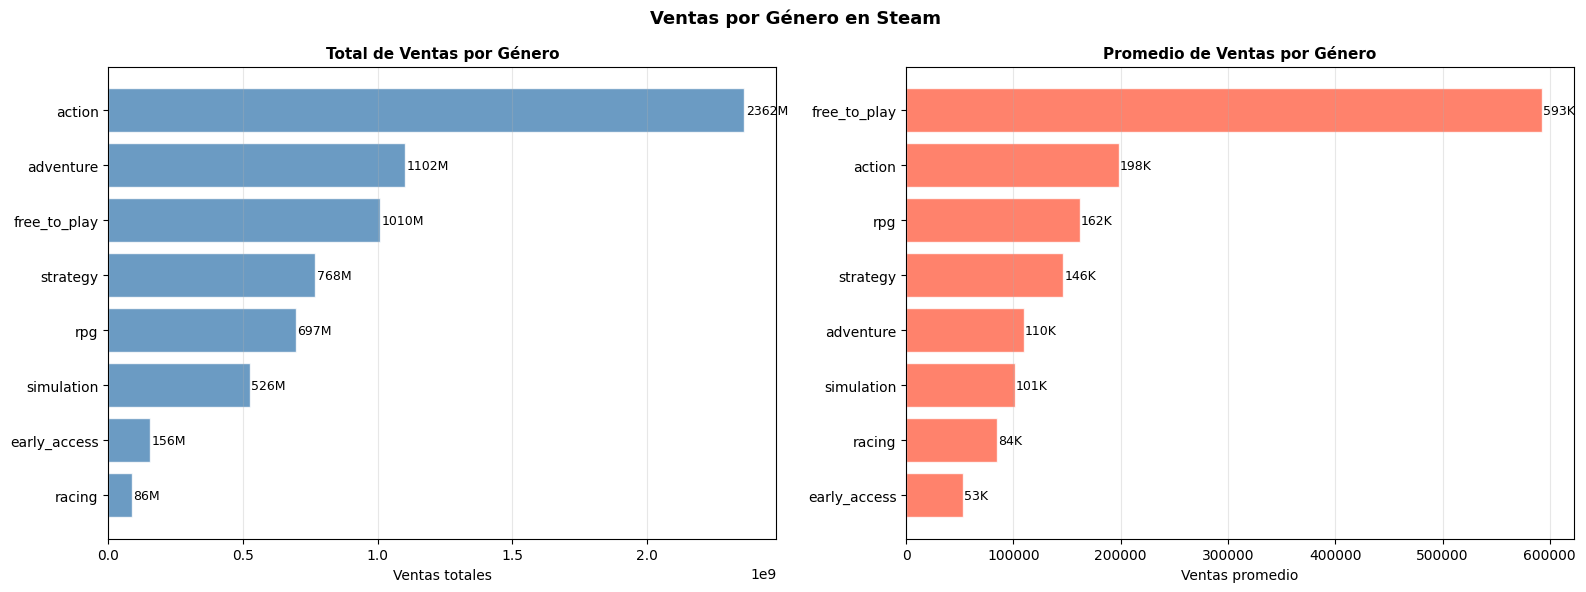

In [90]:
#Organizar valores y generos

generos = ['action', 'adventure', 'rpg', 'simulation',
           'strategy', 'racing', 'free_to_play', 'early_access']

ventas_genero = []
for genero in generos:
    total = df[df[genero] == True]['sells'].sum()
    promedio = df[df[genero] == True]['sells'].mean()
    cantidad = df[df[genero] == True].shape[0]
    ventas_genero.append({
        'genero': genero,
        'total_ventas': total,
        'promedio_ventas': promedio,
        'cantidad_juegos': cantidad
    })

df_generos = pd.DataFrame(ventas_genero).sort_values('total_ventas', ascending=True)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total de ventas por género
bars = axes[0].barh(df_generos['genero'], df_generos['total_ventas'],
                    color='steelblue', alpha=0.8, edgecolor='white')
for bar, val in zip(bars, df_generos['total_ventas']):
    axes[0].text(bar.get_width() + 5e6, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.0f}M', va='center', fontsize=9)
axes[0].set_title('Total de Ventas por Género', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ventas totales')
axes[0].grid(axis='x', alpha=0.3)

# Promedio de ventas por género
df_generos_sorted = df_generos.sort_values('promedio_ventas', ascending=True)
bars2 = axes[1].barh(df_generos_sorted['genero'], df_generos_sorted['promedio_ventas'],
                     color='tomato', alpha=0.8, edgecolor='white')
for bar, val in zip(bars2, df_generos_sorted['promedio_ventas']):
    axes[1].text(bar.get_width() + 1e3, bar.get_y() + bar.get_height()/2,
                 f'{val/1e3:.0f}K', va='center', fontsize=9)
axes[1].set_title('Promedio de Ventas por Género', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ventas promedio')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Ventas por Género en Steam', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 	 Precio vs Ventas

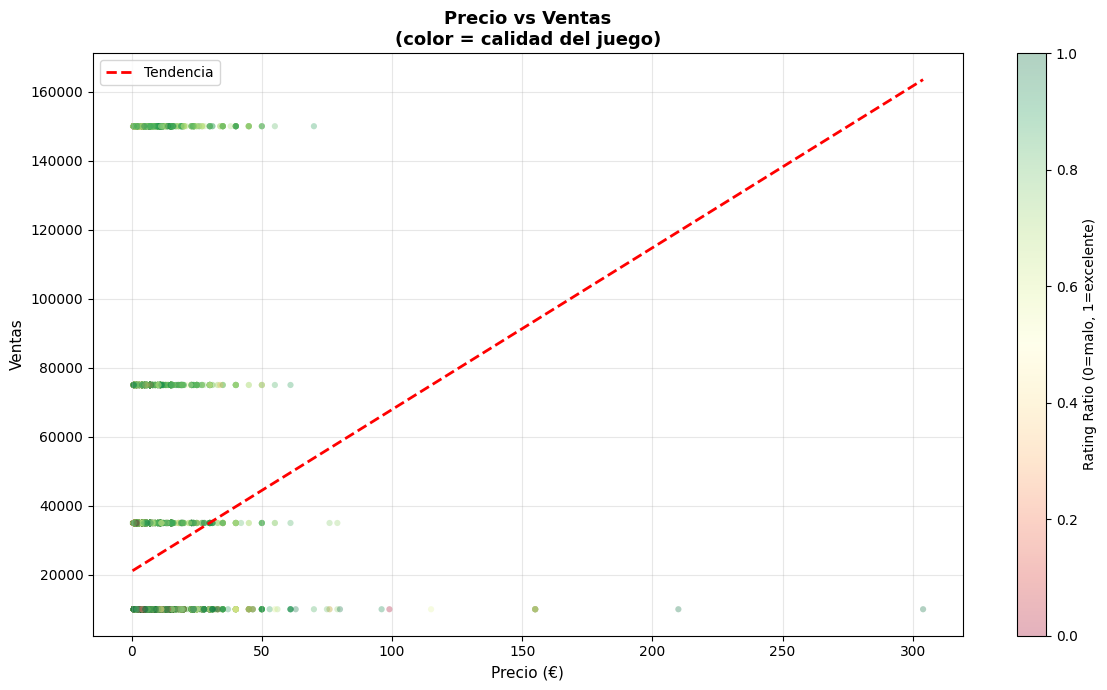

In [91]:

# Filtramos juegos de pago (precio > 0) y removemos outliers extremos

df_pago = df[(df['price'] > 0) & (df['sells'] < df['sells'].quantile(0.95))].copy()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_pago['price'], df_pago['sells'],
                      alpha=0.3,
                      c=df_pago['rating_ratio'],
                      cmap='RdYlGn',
                      s=20,
                      edgecolors='none')

# Línea de tendencia
z = np.polyfit(df_pago['price'], df_pago['sells'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_pago['price'].min(), df_pago['price'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia')

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Rating Ratio (0=malo, 1=excelente)', fontsize=10)

plt.xlabel('Precio (€)', fontsize=11)
plt.ylabel('Ventas', fontsize=11)
plt.title('Precio vs Ventas\n(color = calidad del juego)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 	 Free-to-Play vs De Pago

/tmp/ipykernel_25739/2723430542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([datos_ftp, datos_pago],


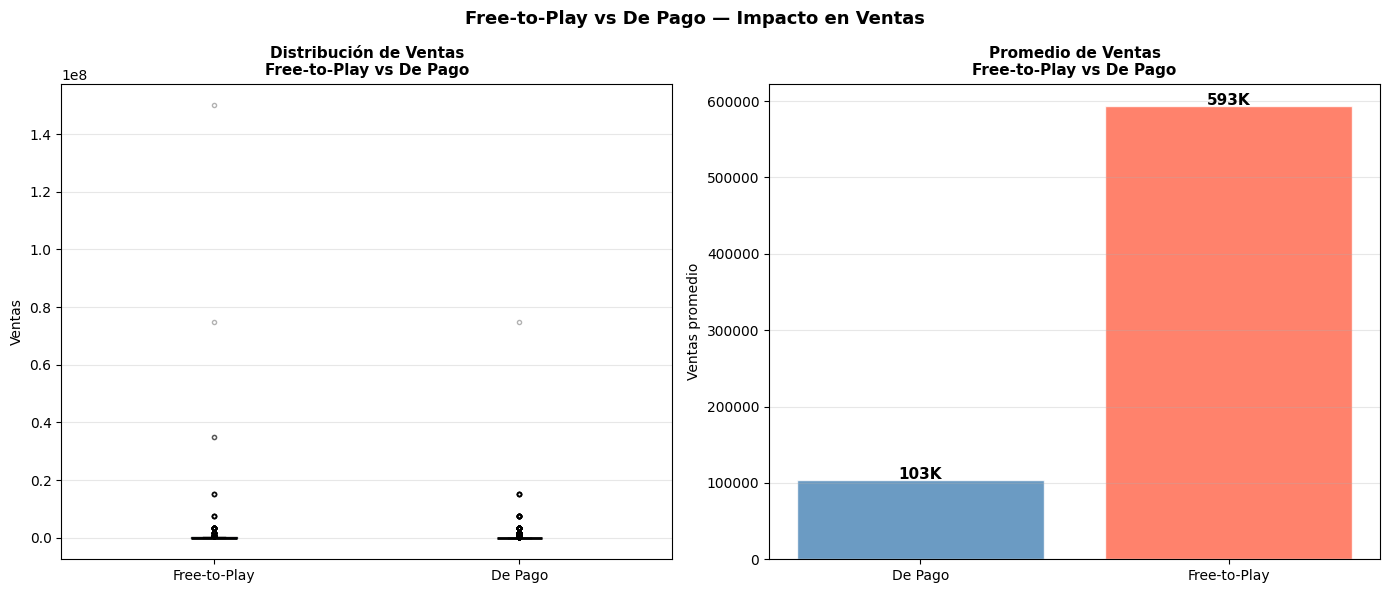

In [92]:

df['tipo'] = df['free_to_play'].map({True: 'Free-to-Play', False: 'De Pago'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1 — Boxplot de ventas
datos_ftp = df[df['tipo'] == 'Free-to-Play']['sells']
datos_pago = df[df['tipo'] == 'De Pago']['sells']

bp = axes[0].boxplot([datos_ftp, datos_pago],
                     patch_artist=True,
                     labels=['Free-to-Play', 'De Pago'],
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')

axes[0].set_title('Distribución de Ventas\nFree-to-Play vs De Pago',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Ventas')
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2 — Promedio de ventas por tipo
promedios = df.groupby('tipo')['sells'].mean().reset_index()
colores_bar = ['steelblue', 'tomato']
bars = axes[1].bar(promedios['tipo'], promedios['sells'],
                   color=colores_bar, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, promedios['sells']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val/1e3:.0f}K', ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Promedio de Ventas\nFree-to-Play vs De Pago',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Ventas promedio')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Free-to-Play vs De Pago — Impacto en Ventas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Free-to-Play vs Reviews

/tmp/ipykernel_25739/3093146922.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([datos_ftp_ratio, datos_pago_ratio],


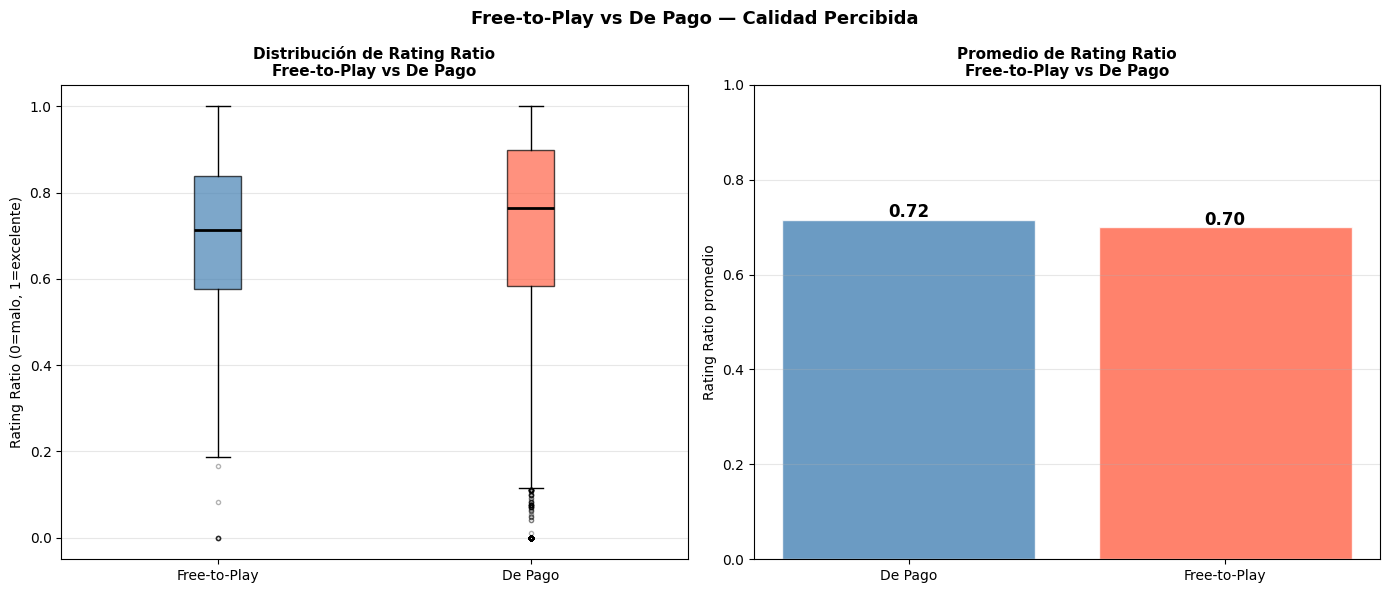

In [93]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1 — Boxplot de rating_ratio por tipo
datos_ftp_ratio = df[df['tipo'] == 'Free-to-Play']['rating_ratio'].dropna()
datos_pago_ratio = df[df['tipo'] == 'De Pago']['rating_ratio'].dropna()

bp = axes[0].boxplot([datos_ftp_ratio, datos_pago_ratio],
                     patch_artist=True,
                     labels=['Free-to-Play', 'De Pago'],
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')

axes[0].set_title('Distribución de Rating Ratio\nFree-to-Play vs De Pago',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rating Ratio (0=malo, 1=excelente)')
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2 — Promedio de rating_ratio por tipo
promedio_ratio = df.groupby('tipo')['rating_ratio'].mean().reset_index()
bars = axes[1].bar(promedio_ratio['tipo'], promedio_ratio['rating_ratio'],
                   color=['steelblue', 'tomato'], alpha=0.8, edgecolor='white')

for bar, val in zip(bars, promedio_ratio['rating_ratio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

axes[1].set_title('Promedio de Rating Ratio\nFree-to-Play vs De Pago',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rating Ratio promedio')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Free-to-Play vs De Pago — Calidad Percibida',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Evolución de Achievements por año

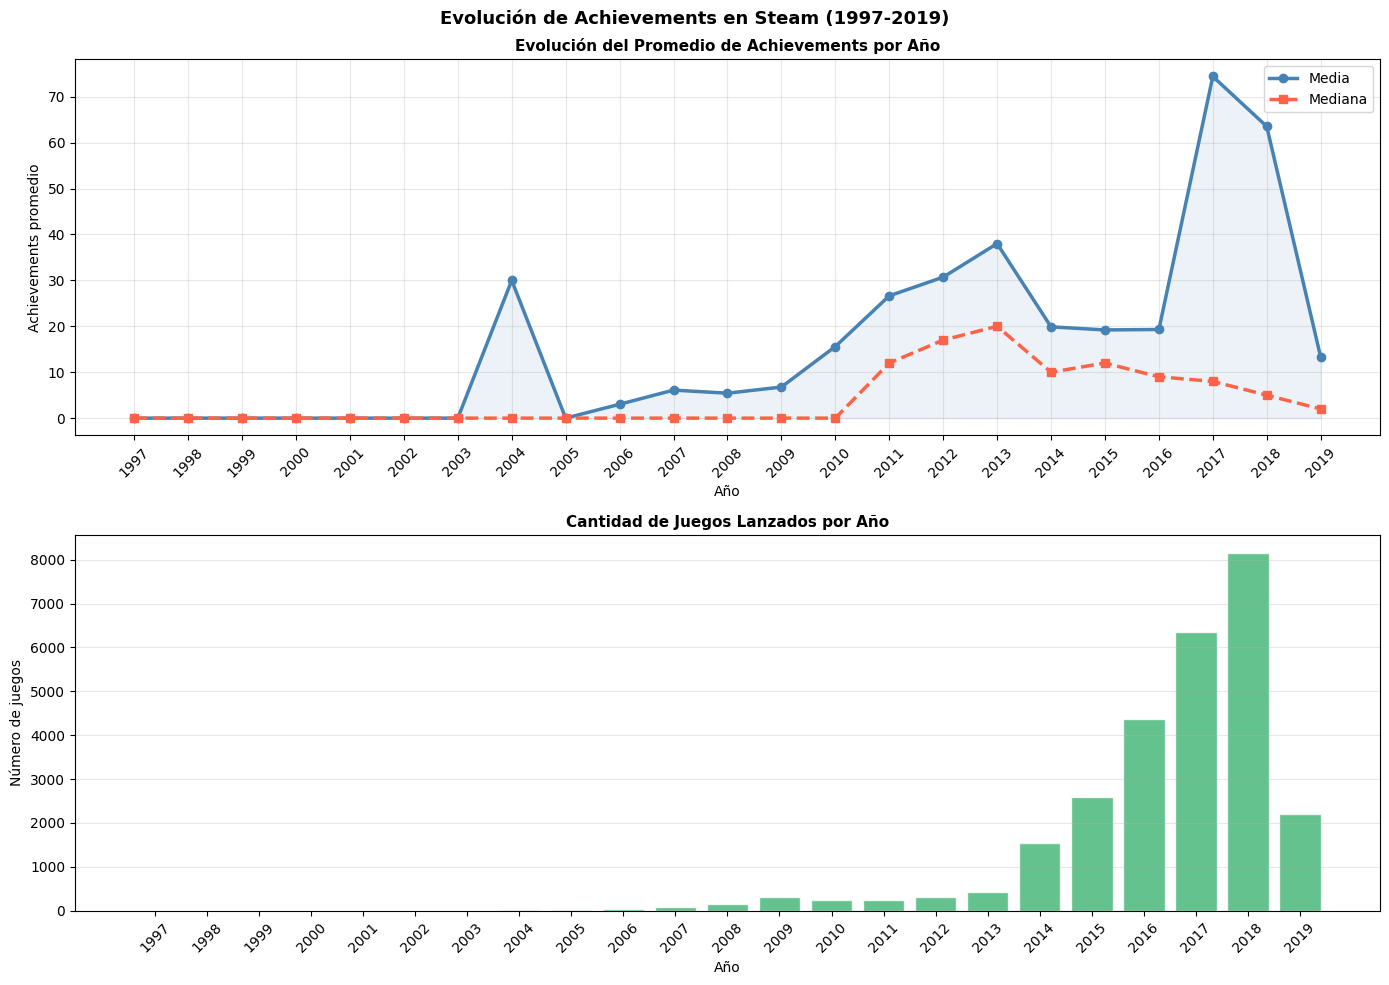

In [94]:

# Extraer año de release_date
df['year'] = df['release_date'].dt.year


# Promedio de achievements por año
evo_achievements = df.groupby('year')['achievements'].agg(
    ['mean', 'median', 'count']).reset_index()
evo_achievements.columns = ['year', 'media', 'mediana', 'cantidad_juegos']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1 — Evolución de achievements promedio
axes[0].plot(evo_achievements['year'], evo_achievements['media'],
             color='steelblue', linewidth=2.5, marker='o',
             markersize=6, label='Media')
axes[0].plot(evo_achievements['year'], evo_achievements['mediana'],
             color='tomato', linewidth=2.5, marker='s',
             markersize=6, linestyle='--', label='Mediana')
axes[0].fill_between(evo_achievements['year'],
                     evo_achievements['media'],
                     alpha=0.1, color='steelblue')
axes[0].set_title('Evolución del Promedio de Achievements por Año',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Achievements promedio')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(evo_achievements['year'])
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2 — Cantidad de juegos lanzados por año
axes[1].bar(evo_achievements['year'], evo_achievements['cantidad_juegos'],
            color='mediumseagreen', alpha=0.8, edgecolor='white')
axes[1].set_title('Cantidad de Juegos Lanzados por Año',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de juegos')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(evo_achievements['year'])
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Evolución de Achievements en Steam (1997-2019)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Horas jugadas por género

Juegos con horas registradas: 6169


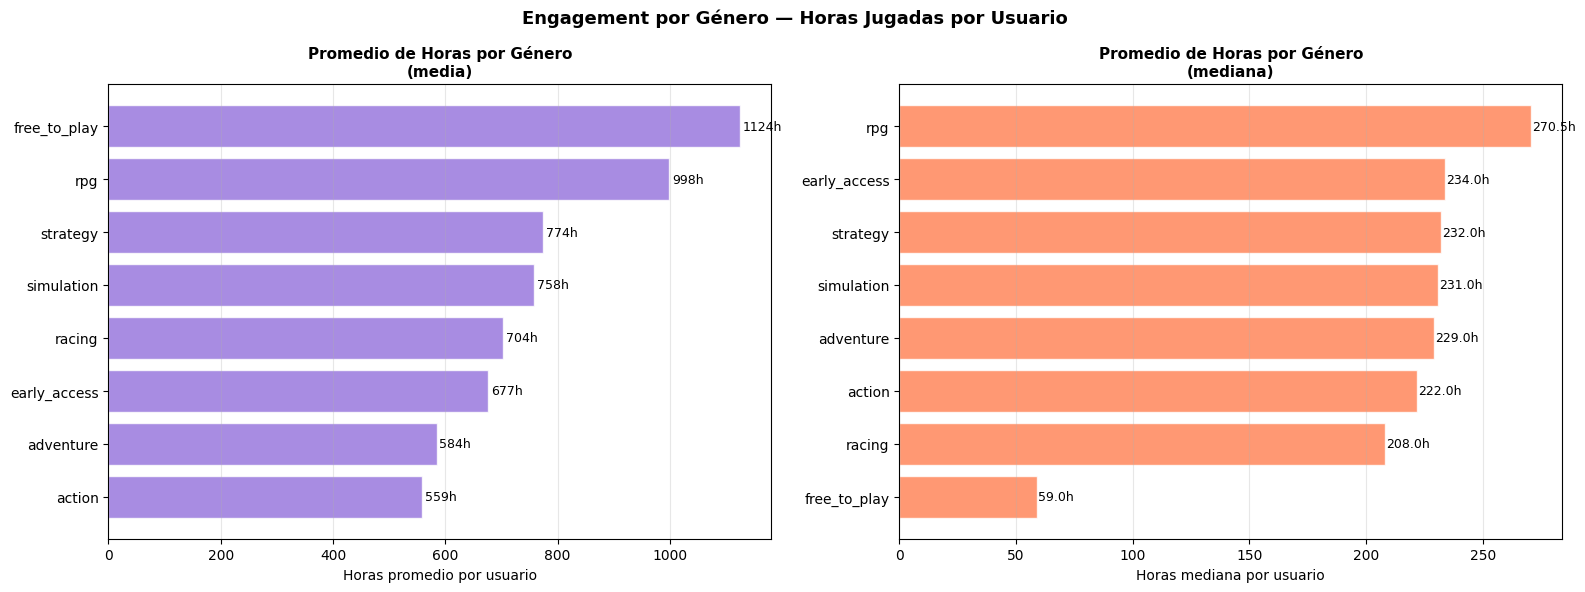

In [95]:

#df solo con horas registradas >0
df_con_horas = df[df['avg_hours_per_user'] > 0].copy()
print(f"Juegos con horas registradas: {len(df_con_horas)}")


# Usamos df_con_horas (solo juegos con horas registradas)
generos = ['action', 'adventure', 'rpg', 'simulation',
           'strategy', 'racing', 'free_to_play', 'early_access']

horas_genero = []
for genero in generos:
    subset = df_con_horas[df_con_horas[genero] == True]['avg_hours_per_user']
    horas_genero.append({
        'genero': genero,
        'media': subset.mean(),
        'mediana': subset.median(),
        'cantidad': len(subset)
    })

df_horas = pd.DataFrame(horas_genero).sort_values('media', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1 — Media de horas por género
bars1 = axes[0].barh(df_horas['genero'], df_horas['media'],
                     color='mediumpurple', alpha=0.8, edgecolor='white')
for bar, val in zip(bars1, df_horas['media']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}h', va='center', fontsize=9)
axes[0].set_title('Promedio de Horas por Género\n(media)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Horas promedio por usuario')
axes[0].grid(axis='x', alpha=0.3)

# Subplot 2 — Mediana de horas por género
df_horas_med = df_horas.sort_values('mediana', ascending=True)
bars2 = axes[1].barh(df_horas_med['genero'], df_horas_med['mediana'],
                     color='coral', alpha=0.8, edgecolor='white')
for bar, val in zip(bars2, df_horas_med['mediana']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}h', va='center', fontsize=9)
axes[1].set_title('Promedio de Horas por Género\n(mediana)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Horas mediana por usuario')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Engagement por Género — Horas Jugadas por Usuario',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Storytelling

#### ¿Qué nos dicen los datos de Steam?

### El mercado de videojuegos visto desde los datos

Steam es la plataforma de videojuegos más grande del mundo, con más de
27,000 títulos publicados hasta 2019. Pero cuando miras los números al
detalle, nos damos cuenta de que:

**no todos juegan bajo las mismas condiciones.**

---

### 1 — Un mercado muy desigual

Los datos dejan algo claro: las ventas están muy concentradas.

Mientras juegos como Dota 2 logran 150 millones de ventas, la mayoría
apenas supera las 10,000 copias (mediana del dataset). La variación es
tan alta (CV = 990%) que los juegos se dividen en dos mundos distintos:
los éxitos mundiales y los 'otros'.

**En Steam, unos pocos juegos se llevan casi todo.**

Sí, es posible vender juegos indie, pero estadísticamente es difícil.

---

### 2 — El precio lo es todo

Se podría concluir que el precio define si un juego vende más o no,
pero no es así: la correlación entre precio y ventas es de apenas 0.03
(prácticamente nula). Hay juegos de 50€ que venden millones y
juegos de 1€ que pasan desapercibidos.

Lo que impacta realmente es:

**La visibilidad.**

Si nadie ve tu juego, no importa su precio, sea el más bajo o el más alto.

---

### 3 — El Free-to-Play cambió todo


Los juegos Free-to-Play tienen muchísimo más alcance: en promedio venden
593K copias por juego, casi 6 veces más que los de pago (103K).Lo
interesante es que la percepción de calidad es prácticamente la misma
(rating ratio: 0.70 vs 0.72).

**Quitar la barrera de entrada dispara la audiencia.**

Es el mismo modelo que vemos en apps y software freemium: construye una
base de usuarios con una entrada gratuita y genera dinero a partir del
ofrecimiento de características premium.

---

### 4 — No todos los juegos enganchan igual

No todos los géneros crean el mismo nivel de compromiso.

Los RPG tienen jugadores que se quedan muchísimo tiempo (270h de mediana).
En cambio, el género Action tiene la mayoria de las ventas pero por enganchan por menos tiempo (222h de mediana).

En resumen:

- RPG y Strategy tienen menos jugadores, pero estos son más fieles (230-270h de mediana)
- Action y Free-to-Play tienen mucha gente pero son más inestables (59-222h de mediana)

**El género define cómo juega la gente y cuánto tiempo se queda.**

---

### 5 — Más juegos, más competencia

Entre 2014 y 2018, la cantidad de juegos en Steam explotó: de ~300 juegos
lanzados en 2013 a más de 8,000 en 2018.

Más desarrolladores equivale a más juegos y esto genera más competencia.

Gracias al aumento en la cantidad de juegos estos empezaron a incluir más logros, alcanzando un promedio histórico de 74 achievements por juego en 2017.
Los desarrolladores respondieron a la competencia añadiendo más
características unicas a sus juegos.

**Cuando hay más competencia, se debe marcar la diferencia**

---

### Conclusión

Al final, los datos nos dicen:

- La **visibilidad** es más importante que el precio (correlación = 0.03)
- El **Free-to-Play** domina en volumen (593K vs 103K ventas promedio)
- La **calidad percibida** no cambia tanto entre modelos (0.70 vs 0.72)
- El **género** define el tipo de jugador que atraes
- La **competencia** empuja a innovar

Y lo mejor: esto no aplica solo a videojuegos.

**Esta estructura es aplicables a cualquier producto de software en un
mercado digital competitivo.**

### Modelos Predictivo

#### Regresión Lineal

In [96]:
#Preparamos las librerias y variables

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Variables
# Convertir free_to_play a 0/1
df['free_to_play_num'] = df['free_to_play'].astype(int)

features = ['price', 'free_to_play_num', 'total_ratings',
            'rating_ratio', 'achievements']

target = 'sells'

# Eliminar filas con nulos en las variables seleccionadas
df_modelo = df[features + [target]].dropna()

X = df_modelo[features]
y = df_modelo[target]

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Total de datos: {len(df_modelo)}")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

Total de datos: 27074
Entrenamiento: 21659 filas
Prueba:        5415 filas


In [97]:
#Entrenamiento del modelo

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")
print(f"\nVariables usadas: {features}")

Modelo entrenado

Variables usadas: ['price', 'free_to_play_num', 'total_ratings', 'rating_ratio', 'achievements']


In [98]:
#Evaluación del Modelo

y_pred = modelo.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test - y_pred))

print("--- MÉTRICAS DEL MODELO ---\n")
print(f"R²   (precisión):      {r2:.4f}")
print(f"RMSE (error promedio): {rmse:,.0f} ventas")
print(f"MAE  (error absoluto): {mae:,.0f} ventas")

--- MÉTRICAS DEL MODELO ---

R²   (precisión):      0.6014
RMSE (error promedio): 454,173 ventas
MAE  (error absoluto): 114,001 ventas


#### Random Forest

In [99]:
#Librerias

from sklearn.ensemble import RandomForestRegressor


In [100]:
#Entrenamiento del modelo

rf_modelo = RandomForestRegressor(
    n_estimators=100,  # 100 árboles
    random_state=42,
    n_jobs=-1          # usa todos los núcleos disponibles
)

rf_modelo.fit(X_train, y_train)
print("Random Forest entrenado correctamente")



Random Forest entrenado correctamente


In [101]:
# Evaluación del modelo
rf_pred = rf_modelo.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = np.mean(np.abs(y_test - rf_pred))

print("\n--- COMPARACIÓN DE MODELOS ---\n")
print(f"{'Métrica':<10} {'Reg. Lineal':>15} {'Random Forest':>15}")
print(f"{'-'*42}")
print(f"{'R²':<10} {0.6014:>15.4f} {rf_r2:>15.4f}")
print(f"{'RMSE':<10} {454173:>15,.0f} {rf_rmse:>15,.0f}")
print(f"{'MAE':<10} {114001:>15,.0f} {rf_mae:>15,.0f}")


--- COMPARACIÓN DE MODELOS ---

Métrica        Reg. Lineal   Random Forest
------------------------------------------
R²                  0.6014          0.6454
RMSE               454,173         428,370
MAE                114,001          67,373


#### Comparación de Modelos

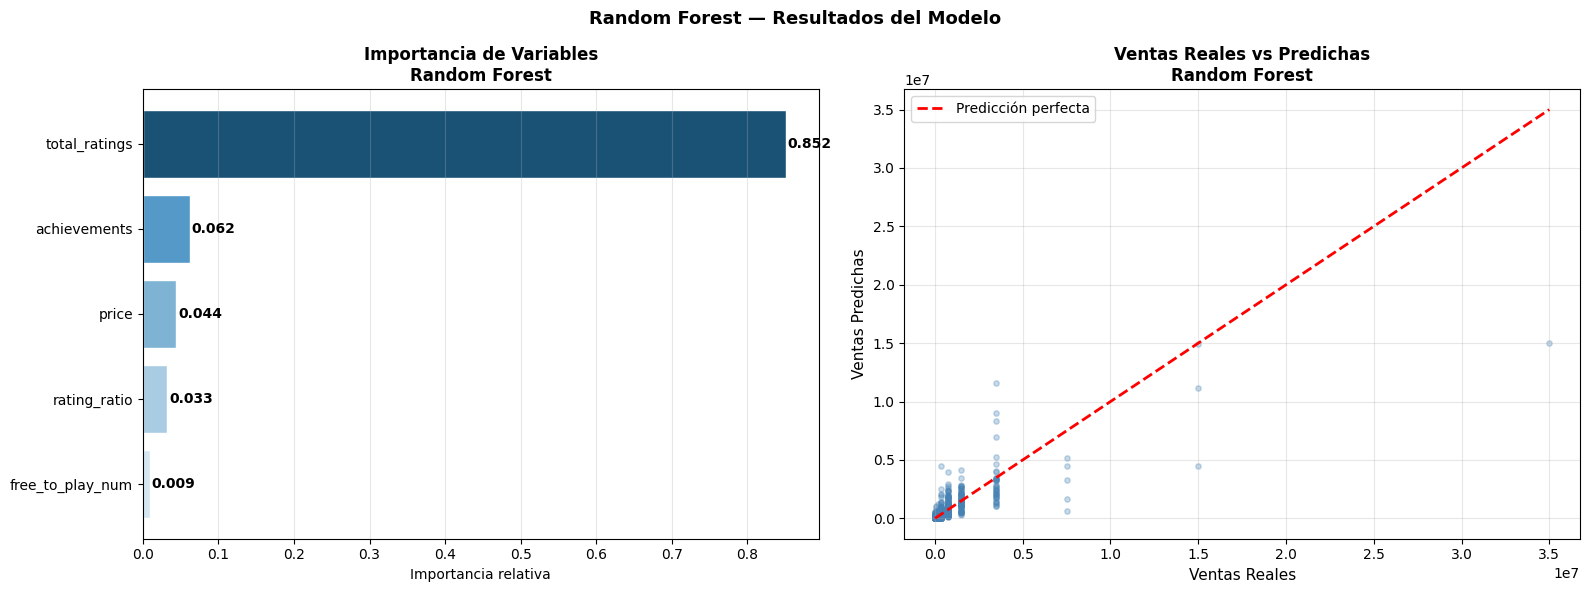

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Gráfico 1: Importancia de variables
importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': rf_modelo.feature_importances_
}).sort_values('Importancia', ascending=True)

colores = ['#d4e6f1', '#a9cce3', '#7fb3d3', '#5499c7', '#1a5276']
bars = axes[0].barh(importancias['Variable'], importancias['Importancia'],
                    color=colores, edgecolor='white')

for bar, val in zip(bars, importancias['Importancia']):
    axes[0].text(bar.get_width() + 0.002,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

axes[0].set_title('Importancia de Variables\nRandom Forest',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia relativa')
axes[0].grid(axis='x', alpha=0.3)

#  Gráfico 2: Real vs Predicho
axes[1].scatter(y_test, rf_pred, alpha=0.3,
                color='steelblue', s=15)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Ventas Reales', fontsize=11)
axes[1].set_ylabel('Ventas Predichas', fontsize=11)
axes[1].set_title('Ventas Reales vs Predichas\nRandom Forest',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Random Forest — Resultados del Modelo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Modelos Predictivos — Comparación

Se entrenaron y compararon dos modelos para predecir las ventas
de un juego en Steam a partir de sus características.

---

**¿Qué hace cada modelo?**

- **Regresión Lineal:** asume que las ventas se pueden predecir
  con una fórmula matemática directa entre variables.
  Simple, rápido e interpretable.

- **Random Forest:** usa 100 árboles de decisión que "votan"
  juntos para predecir. Más flexible, maneja mejor datos
  irregulares y outliers.

---

**Resultados:**

| Métrica | Reg. Lineal | Random Forest | Mejor |
|---------|-------------|---------------|-------|
| R²      | 0.60        | 0.65          |   RF  |
| RMSE    | 454,173     | 428,370       |   RF  |
| MAE     | 114,001     | 67,373        |   RF  |


Random Forest supera a la Regresión Lineal en todas las métricas,
reduciendo el error promedio (MAE) en un 41%.

---

**¿Qué variable importa más?**

El Random Forest reveló que total_ratings (0.852) explica
el 85% de la predicción — el volumen de opiniones es mucho
más determinante que el precio (0.044) o el género (0.009).

Esto confirma matemáticamente la parte 1 del Storytelling:**

La visibilidad y popularidad (medida en ratings) es el factor
más importante del éxito comercial en Steam , por encima
del precio, el género o la calidad percibida.

---

**Limitación compartida:**
Ambos modelos subestiman los grandes éxitos (+15M ventas)
porque el éxito masivo depende de factores no capturados
en los datos: marketing, momento de lanzamiento y viralidad.